# Qicheng Sun。 82857。Lab 10




EUROSTAT dataset: **UNE_RT_M** - Unemployment by sex and age - monthly data

Documentation: https://ec.europa.eu/eurostat/databrowser/view/une_rt_m/default/table

## Google Colab setup

1. Upload the whole **`Lab-10`** folder to Colab (or to Google Drive).
2. In the cell below, set **`LAB_DIR`** to the folder path where you uploaded it.
3. Run all cells from top to bottom.

**Common paths after upload:**
- Uploaded directly to Colab session: `/content/Lab-10`
- Google Drive: `/content/drive/MyDrive/.../Lab-10` (mount Drive first)

Task 0 downloads EUROSTAT data online. The `data/` CSV files (`orders.csv`, `FIFA22_official_data.csv`) are checked in the setup cell for later tasks.

In [ ]:
from pathlib import Path

# Change only this line to your uploaded folder path:
LAB_DIR = Path("/content/Lab-10")

# Optional: use Google Drive instead
# from google.colab import drive
# drive.mount("/content/drive")
# LAB_DIR = Path("/content/drive/MyDrive/YOUR_FOLDER/Lab-10")

DATA_DIR = LAB_DIR / "data"
ORDERS_PATH = DATA_DIR / "/content/data/orders.csv"
FIFA_PATH = DATA_DIR / "/content/data/FIFA22_official_data.csv"

print("LAB_DIR:", LAB_DIR)
print("LAB_DIR exists:", LAB_DIR.exists())
print("orders.csv:", ORDERS_PATH.exists())
print("FIFA22_official_data.csv:", FIFA_PATH.exists())

LAB_DIR: /content/Lab-10
LAB_DIR exists: False
orders.csv: True
FIFA22_official_data.csv: True


In [ ]:
!pip install eurostat seaborn plotly pandas

In [ ]:
import eurostat
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns

### Load `orders.csv` (same as in the lab notebook)

In [ ]:
df = pd.read_csv(ORDERS_PATH, sep=";")
df["OrderDate"] = pd.to_datetime(df["OrderDate"])
df.head()

,Country,Seller,OrderDate,OrderId,OrderValue
0,Polska,Kowalski,2003-07-16,10248,440.00
1,Polska,Sowiński,2003-07-10,10249,1863.40
2,Niemcy,Peacock,2003-07-12,10250,1552.60
3,Niemcy,Leverling,2003-07-15,10251,654.06
4,Niemcy,Peacock,2003-07-11,10252,3597.90


**Stage 1 - initial exploration**

In [ ]:
print(eurostat.get_pars("UNE_RT_M"))

data = eurostat.get_data_df("UNE_RT_M")
data.info()

print("Dataset size in memory [MB]:", sum(data.memory_usage(deep=True)) / 1024 / 1024)
data.head(10)

['freq', 's_adj', 'age', 'unit', 'sex', 'geo']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2005 entries, 0 to 2004
Columns: 526 entries, freq to 2026-04
dtypes: float64(520), object(6)
memory usage: 8.0+ MB
Dataset size in memory [MB]: 8.552543640136719


,freq,s_adj,age,unit,sex,geo\TIME_PERIOD,1983-01,1983-02,1983-03,1983-04,...,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04
0,M,NSA,TOTAL,PC_ACT,F,AT,NaN,NaN,NaN,NaN,...,5.5,5.3,5.1,5.2,5.3,6.0,5.5,6.3,5.9,5.3
1,M,NSA,TOTAL,PC_ACT,F,BA,NaN,NaN,NaN,NaN,...,16.0,16.0,15.7,15.7,15.7,15.7,16.6,16.5,16.4,NaN
2,M,NSA,TOTAL,PC_ACT,F,BE,NaN,NaN,NaN,NaN,...,5.8,6.1,6.2,6.2,6.1,6.2,6.2,6.1,6.0,5.9
3,M,NSA,TOTAL,PC_ACT,F,BG,NaN,NaN,NaN,NaN,...,3.3,3.1,2.9,3.0,3.0,3.0,3.1,3.1,3.1,3.0
4,M,NSA,TOTAL,PC_ACT,F,CH,NaN,NaN,NaN,NaN,...,5.0,5.2,5.2,5.1,5.1,5.1,5.0,5.0,5.1,NaN
5,M,NSA,TOTAL,PC_ACT,F,CY,NaN,NaN,NaN,NaN,...,5.6,5.1,3.0,3.0,4.8,5.0,4.6,4.0,3.5,2.9
6,M,NSA,TOTAL,PC_ACT,F,CZ,NaN,NaN,NaN,NaN,...,3.1,3.9,3.3,3.4,3.6,3.6,3.8,3.8,3.8,3.4
7,M,NSA,TOTAL,PC_ACT,F,DE,NaN,NaN,NaN,NaN,...,3.3,3.5,3.9,3.4,3.5,3.3,3.8,3.5,3.6,3.5
8,M,NSA,TOTAL,PC_ACT,F,DK,8.9,9.1,9.0,8.9,...,6.1,6.6,6.4,6.5,6.8,5.5,8.8,8.8,6.2,7.0
9,M,NSA,TOTAL,PC_ACT,F,EA21,NaN,NaN,NaN,NaN,...,6.5,6.7,6.7,6.5,6.3,6.3,6.7,6.8,6.7,6.4


In [ ]:
data = data.rename(columns={r"geo\TIME_PERIOD": "geo"})
data.isna().sum().sort_values(ascending=False).head()

,0
1984-03,1512
1984-04,1512
1984-05,1512
1984-06,1512
1984-07,1512


In [ ]:
non_na_rows = data[data.isna().sum(axis=1) == 0]
print("Rows without missing values:", non_na_rows.shape[0])
print("Unique countries:", data["geo"].nunique())
print("Unique sex values:", data["sex"].unique())
print("Unique age groups:", data["age"].unique())
print("Unique units:", data["unit"].unique())
print("Seasonal adjustment types:", data["s_adj"].unique())

Rows without missing values: 353
Unique countries: 38
Unique sex values: ['F' 'M' 'T']
Unique age groups: ['TOTAL' 'Y25-74' 'Y_LT25']
Unique units: ['PC_ACT' 'THS_PER']
Seasonal adjustment types: ['NSA' 'SA' 'TC']


In [ ]:
num_cols = data.dtypes[data.dtypes == "float64"].index.values

countries = ["PL", "DE", "FR", "CZ", "SE"]
base_filter = (
    (data["sex"] == "T")
    & (data["age"] == "TOTAL")
    & (data["unit"] == "PC_ACT")
    & (data["s_adj"] == "NSA")
)

subset = data[base_filter & data["geo"].isin(countries)]
subset[["geo", "sex", "age", "unit", "s_adj"]]

,geo,sex,age,unit,s_adj
82,CZ,T,TOTAL,PC_ACT,NSA
83,DE,T,TOTAL,PC_ACT,NSA
91,FR,T,TOTAL,PC_ACT,NSA
105,PL,T,TOTAL,PC_ACT,NSA
108,SE,T,TOTAL,PC_ACT,NSA


**1. What does the unemployment rate trend for Poland look like?**

In [ ]:
df_pl = data[base_filter & (data["geo"] == "PL")]
plot_data = df_pl.loc[:, num_cols].dropna(axis=1)
plot_data

,1997-01,1997-02,1997-03,1997-04,1997-05,1997-06,1997-07,1997-08,1997-09,1997-10,...,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04
105,12.2,12.1,11.9,11.4,11.0,10.8,10.7,10.4,10.2,9.9,...,3.0,3.2,3.2,3.2,3.2,3.2,3.3,3.3,3.2,2.9


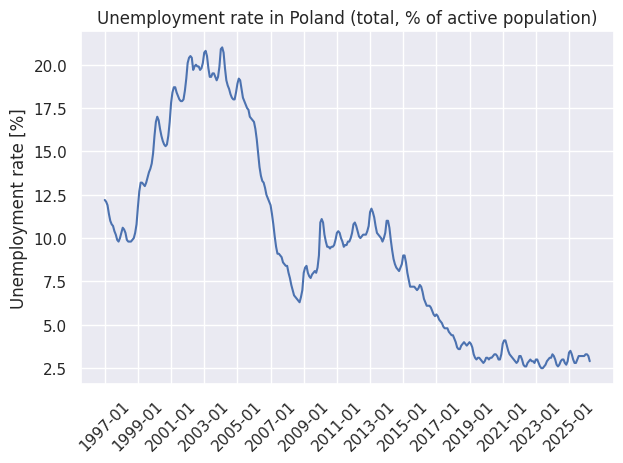

In [ ]:
sns.set()
g = sns.lineplot(plot_data.T, legend=False)
plt.title("Unemployment rate in Poland (total, % of active population)")
plt.ylabel("Unemployment rate [%]")
plt.xticks(plot_data.T.index[::24].values, plot_data.T.index[::24].values, rotation=45)
plt.tight_layout()
plt.show()

**2. How does Poland compare with Germany, France, Czech Republic and Sweden?**

In [ ]:
plot_data_countries = subset.set_index("geo").loc[:, num_cols].dropna(axis=1)
plot_long = (
    plot_data_countries.reset_index()
    .melt(id_vars="geo", var_name="month", value_name="unemployment_rate")
    .dropna()
)
plot_long["month"] = pd.to_datetime(plot_long["month"])

fig = px.line(
    plot_long,
    x="month",
    y="unemployment_rate",
    color="geo",
    title="Monthly unemployment rate comparison (selected EU countries)",
    labels={"unemployment_rate": "Unemployment rate [%]", "month": "Month", "geo": "Country"},
)
fig.show()

**3. What does unemployment look like broken down by gender in Poland?**

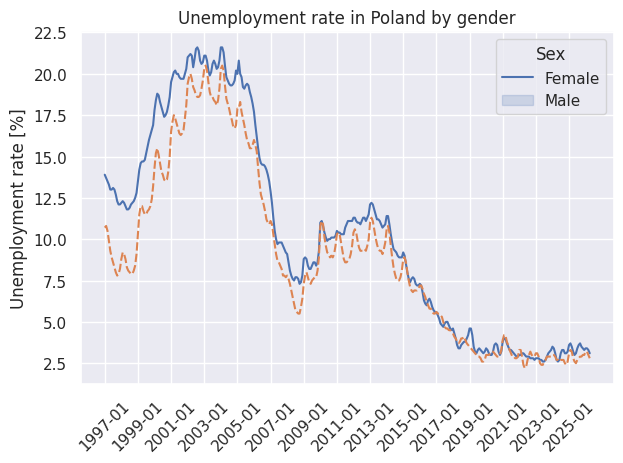

In [ ]:
df_pl_gender = data[
    (data["geo"] == "PL")
    & (data["age"] == "TOTAL")
    & (data["unit"] == "PC_ACT")
    & (data["s_adj"] == "NSA")
    & (data["sex"].isin(["F", "M"]))
]
plot_data_gender = df_pl_gender.set_index("sex").loc[:, num_cols].dropna(axis=1)

g = sns.lineplot(plot_data_gender.T)
g.ticklabel_format(style="plain", axis="y")
plt.title("Unemployment rate in Poland by gender")
plt.ylabel("Unemployment rate [%]")
plt.xticks(plot_data_gender.T.index[::24].values, plot_data_gender.T.index[::24].values, rotation=45)
plt.legend(title="Sex", labels=["Female", "Male"])
plt.tight_layout()
plt.show()

**4. Structure of unemployment in 2024 for selected countries**

In [ ]:
recent_cols = [col for col in num_cols if col.startswith("2024")]
structure_2024 = (
    subset[["geo"] + recent_cols]
    .groupby("geo", as_index=False)
    .mean(numeric_only=True)
    .melt(id_vars="geo", var_name="month", value_name="unemployment_rate")
    .dropna()
    .groupby("geo", as_index=False)["unemployment_rate"]
    .mean()
    .rename(columns={"unemployment_rate": "avg_unemployment_2024"})
    .sort_values("avg_unemployment_2024", ascending=False)
)

fig = px.bar(
    structure_2024,
    x="geo",
    y="avg_unemployment_2024",
    color="geo",
    title="Average monthly unemployment rate in 2024",
    labels={"avg_unemployment_2024": "Average unemployment rate [%]", "geo": "Country"},
)
fig.show()